In [13]:
# Topic: Salary Prediction using Polynomial Regression
# Problem Statement: A company wants to estimate the salary of employees based on their position level. Since the relationship between position level and salary is non-linear,
# develop a Polynomial Regression model to predict employee salaries.

#📊 Dataset
# Position Salaries Dataset
# Kaggle Link: https://www.kaggle.com/datasets/akram24/position-salaries

import kagglehub

path = kagglehub.dataset_download("akram24/position-salaries")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'position-salaries' dataset.
Path to dataset files: /kaggle/input/position-salaries


In [5]:
# Task 1: Data Understanding

import pandas as pd

df = pd.read_csv('/kaggle/input/position-salaries/Position_Salaries.csv')

print("--- First 5 Records ---")
print(df.head())

print("\n--- Dataset Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

--- First 5 Records ---
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None

--- Summary Statistics ---
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


In [6]:
# Task 2: Data Preprocessing

from sklearn.model_selection import train_test_split

print("--- Missing Values ---")
print(df.isnull().sum())

X = df[['Level']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

--- Missing Values ---
Position    0
Level       0
Salary      0
dtype: int64


In [7]:
# Task 3: Model Development

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred = poly_model.predict(X_test_poly)

Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R2 Score: 0.8763


/tmp/ipykernel_854/3674549520.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1).reshape(-1, 1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


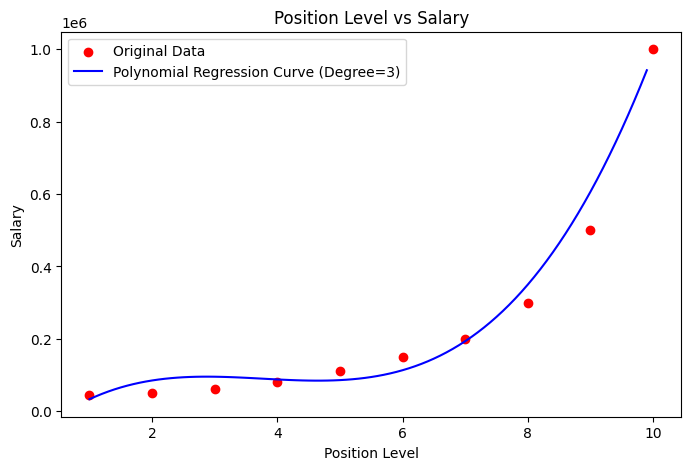

In [9]:
# Task 4: Model Evaluation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

X_grid = np.arange(min(X.values), max(X.values), 0.1).reshape(-1, 1)
y_grid_pred = poly_model.predict(poly.transform(X_grid))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', label='Original Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression Curve (Degree=3)')
plt.title('Position Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

Task 5: Conclusion

The Polynomial Regression model successfully mapped the relationship between employee position levels and their corresponding salaries. Our key finding is that salaries do not scale uniformly; they remain relatively flat at lower hierarchical levels but scale exponentially at the executive tiers (Levels 8-10).

The primary difference between standard Linear Regression and Polynomial Regression is how they fit the data. Linear Regression attempts to draw a single straight line through the data points, which would severely underfit this dataset and result in massive prediction errors for higher levels. Polynomial regression resolves this by adding squared and cubed terms to the equation, allowing the regression line to bend.

The greatest advantage of Polynomial Regression for this specific dataset is its flexibility. It effortlessly captures the non-linear, compounding nature of corporate compensation without requiring us to manually log-transform the target variable.